### Dataset and Task Metadata

In [5]:
from data_foundry.schema import DatasetMetadata, PredictiveMLTaskMetadata

dataset_mold = DatasetMetadata(
    unique_name="hotel_booking_demand",
    dataset_year="2019",
    domain_str="business & marketing",
    # Data Source
    dataset_source="Other",
    original_dataset_source_download_link="https://www.sciencedirect.com/science/article/pii/S2352340918315191#s0005",
    download_description=r"""
    mkdir -p local-data-warehouse/hotel_booking_demand 
    wget -P local-data-warehouse/hotel_booking_demand/ https://ars.els-cdn.com/content/image/1-s2.0-S2352340918315191-mmc2.zip
    unzip local-data-warehouse/hotel_booking_demand/1-s2.0-S2352340918315191-mmc2.zip -d local-data-warehouse/hotel_booking_demand/ 
    rm local-data-warehouse/hotel_booking_demand/1-s2.0-S2352340918315191-mmc2.zip
""",
    # References
    academic_reference_bibtex=r"""@article{antonio2019hotel,
  title={Hotel booking demand datasets},
  author={Antonio, Nuno and de Almeida, Ana and Nunes, Luis},
  journal={Data in brief},
  volume={22},
  pages={41--49},
  year={2019},
  publisher={Elsevier}
}
""",
    academic_reference_bibtex_key="antonio2019hotel",
    license="CC BY 4.0",
    data_tags=["Non-IID", "Temporal"],
    curation_comments="""
    - We concatenate the two datasets H1 (resort hotels) and H2 (city hotels). We add a column "hotel" to indicate the hotel type.
    - Note: The paper shares several thoughts on data curation, looking at them can be insightful for understanding the data and its limitations. 
    - We remove 26.80% duplicates from the data. It is nearly impossible that so many bookings have are booked the same time (# days) in advance on the exact same date for the exact same date. As the paper mentioned that the data was joined from multiple databases, it can be assumed that many duplicates are a data collection artifact, rather than systematic. Therefore, although some duplicates might occur realistically, we remove all duplicates to avoid data leakage.
    - We remove all bookings with a "LeadTime" of 0, assuming that bookings that are booked and canceled on the same day cannot be predicted.
    - Note: The data would allow for a second target to predict no shows.
    - We reconstruct the arrival date from the three columns "ArrivalDateYear", "ArrivalDateMonth", and "ArrivalDateDayOfMonth".
    - We create a "booking_date" column by subtracting the "LeadTime" from the "arrival_date". This is necessary to further define the prediction point in time and to filter the data to avoid data leakage.   
    - To define train/test splits, we define 9 points in time each starting on the 1st of a month. Using the available time stamps we separate bookings that lie in the future, and were not canceled yet as the test data.
    - To account for the fact that, the available bookings suddenly stop at the latest month, the latest prediction point is set to three months before the end of the recorded period. This is necessary to avoid an unrealistic distribution shift in the test data, as the later prediction points don't include bookings  for later time points that would typically be available.  
    - To make sure that the training data reflects the forecasting horizon, we remove all historical bookings that were canceled more than three months in advance. Note that we made this choice based on assumptions without actually testing the impact of this decision. It would be interesting to test the impact of this decision on prediction performance.
    - Bookings that have arrival dates in the future, but were already canceled at the given prediction point are included in the train data. 
    - After splitting, we remove "ReservationStatus" and "ReservationStatusDate" to avoid data leakage.
    - Anomaly: The first recorded month for the city hotels shows an unusually high amount of cancellations.
""",
)
task_mold = PredictiveMLTaskMetadata(
    target_column_name="IsCanceled",
    problem_type="binary_classification",
    objective_metric_name="roc_auc",
    stratify_on="IsCanceled",
    time_on="arrival_date"
)

## Preprocessing

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

h1 = pd.read_csv(dataset_mold.path / "H1.csv")
h2 = pd.read_csv(dataset_mold.path / "H2.csv")

h1["hotel"] = "resort"
h2["hotel"] = "city"

# Merge data
df = pd.concat([h1, h2], ignore_index=True).reset_index(drop=True)

# Restore arrival date
df["arrival_date"] = pd.to_datetime(df["ArrivalDateYear"].astype(str) + "-" + df["ArrivalDateMonth"] + "-" + df["ArrivalDateDayOfMonth"].astype(str))
df["ReservationStatusDate"] = pd.to_datetime(df["ReservationStatusDate"])

# Drop all duplicates
df = df.drop_duplicates().reset_index(drop=True)
df = df.loc[df["LeadTime"]>0].reset_index(drop=True)

# Create booking date column
df["booking_date"] = (df["arrival_date"] - pd.to_timedelta(df["LeadTime"], unit='d'))

cat_cols = [
    "Country",
    "ArrivalDateMonth",
    "Meal",
    "MarketSegment",
    "DistributionChannel",
    "ReservedRoomType",
    "AssignedRoomType",
    "DepositType",
    "Agent",
    "Company",
    "CustomerType",
    "ReservationStatus",
    "hotel",
]

df[cat_cols] = df[cat_cols].astype("category")

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Loaded data shape:", df.shape)

Loaded data shape: (81418, 34)


In [7]:
df[["booking_date", "arrival_date", "ReservationStatusDate"]].describe()

,booking_date,arrival_date,ReservationStatusDate
count,81418,81418,81418
mean,2016-06-26 02:22:46.990100480,2016-09-19 20:33:15.745412608,2016-09-03 19:09:43.743152640
min,2013-06-24 00:00:00,2015-07-01 00:00:00,2014-10-17 00:00:00
25%,2016-01-19 00:00:00,2016-04-10 00:00:00,2016-03-24 00:00:00
50%,2016-07-03 00:00:00,2016-09-25 00:00:00,2016-09-12 00:00:00
75%,2017-01-06 00:00:00,2017-04-07 00:00:00,2017-03-09 00:00:00
max,2017-08-30 00:00:00,2017-08-31 00:00:00,2017-09-14 00:00:00


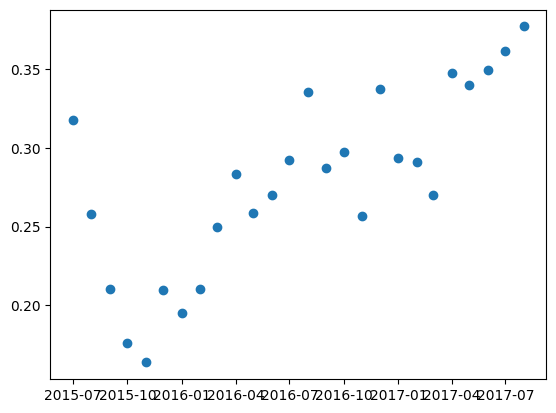

In [8]:
# There are seasonal patterns, but also a long-term trend towards more cancellations.
mean_per_month = df["IsCanceled"].groupby(pd.to_datetime(df[["ArrivalDateYear","ArrivalDateMonth"]].astype(str).agg('-'.join, axis=1) + '-01')).mean()
plt.scatter(mean_per_month.index,mean_per_month.values)

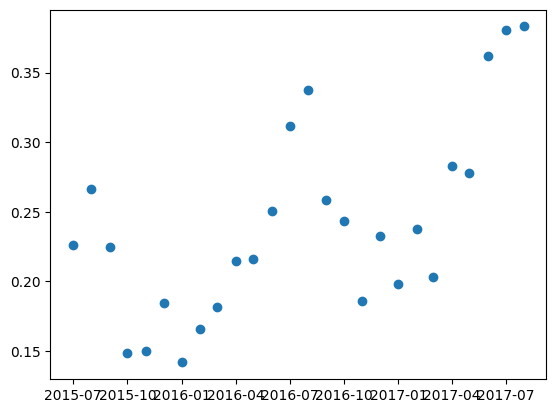

In [9]:
# There are seasonal patterns, but also a long-term trend towards more cancellations.
df_resort = df[df["hotel"] == "resort"]
mean_per_month = df_resort["IsCanceled"].groupby(pd.to_datetime(df_resort[["ArrivalDateYear","ArrivalDateMonth"]].astype(str).agg('-'.join, axis=1) + '-01')).mean()
plt.scatter(mean_per_month.index,mean_per_month.values)

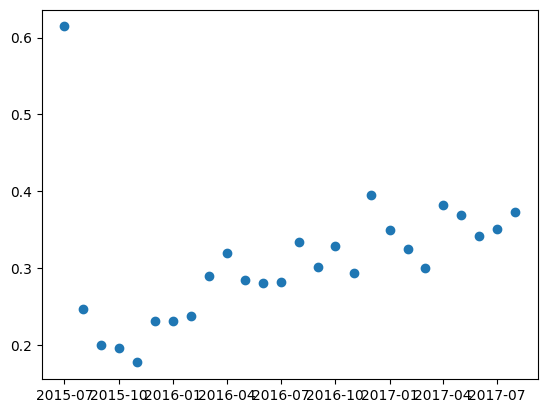

In [10]:
# There are seasonal patterns, but also a long-term trend towards more cancellations.
df_city = df[df["hotel"] == "city"]
mean_per_month = df_city["IsCanceled"].groupby(pd.to_datetime(df_city[["ArrivalDateYear","ArrivalDateMonth"]].astype(str).agg('-'.join, axis=1) + '-01')).mean()
plt.scatter(mean_per_month.index,mean_per_month.values)

In [11]:
# df_city.loc[df_city["arrival_date"]<pd.to_datetime("2015-08-01"),"IsCanceled"].mean()
df_city.loc[np.logical_and(df_city["arrival_date"]<pd.to_datetime("2015-08-01"), df_city["booking_date"]<pd.to_datetime("2015-07-01")),"IsCanceled"].describe()

count    322.000000
mean       0.698758
std        0.459512
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: IsCanceled, dtype: float64

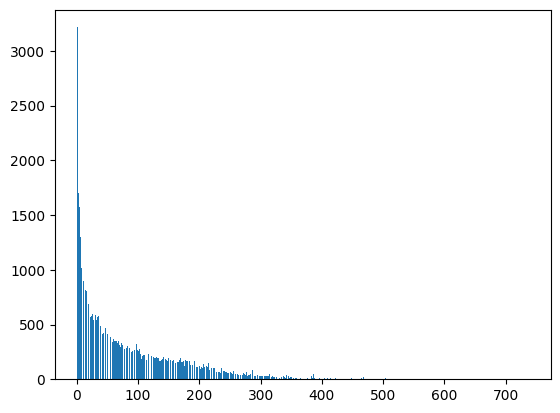

In [12]:
# Most bookings are made close to the arrival date, but there are also some bookings with a very long lead time.
import matplotlib.pyplot as plt
_ = plt.hist(df["LeadTime"], bins=1000)

In [13]:
# # Inspect duplicates
# duplicates = df.loc[df.duplicated(keep=False)]
# row_key = duplicates.astype(str).agg('|'.join, axis=1)
# row_hash = row_key.map(hash)   # okay for quick use, but not stable across runs

# duplicates_sorted = duplicates.assign(_hash=row_hash).sort_values('_hash')
# duplicates_sorted.head(7).T
# Decision: Drop all duplicates, as it is nearly impossible that so many bookings have are booked the same amouint of days in advance on the exact same date for the exact same date. As the paper mentioned that the data was joined from multiple databases, it can be assumed that this is a data colelction artifact, rather than systematic.

In [14]:
# Find out how many days in advance the status was changed
status_change_prior_booking = (df["arrival_date"]-pd.to_datetime(df["ReservationStatusDate"])).dt.days

# Whenever the last status change was after the arrival date, the booking was not cancelled. 
df.loc[status_change_prior_booking<0, "IsCanceled"].value_counts()

IsCanceled
0    57364
Name: count, dtype: int64

In [15]:
df.loc[status_change_prior_booking>0, "IsCanceled"].value_counts()

IsCanceled
1    22250
Name: count, dtype: int64

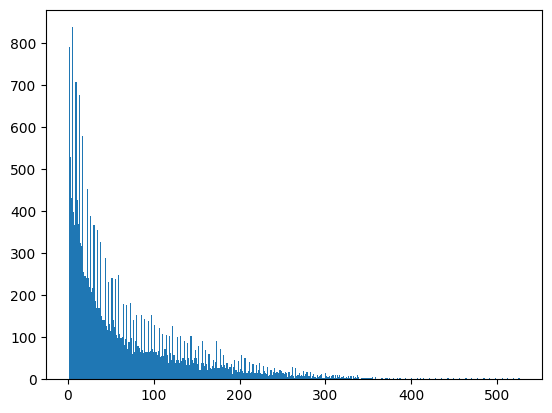

In [16]:
_ = plt.hist(status_change_prior_booking[status_change_prior_booking>0], bins=400)


In [17]:
# need to drop reservation status
pd.crosstab(df["ReservationStatus"], df["IsCanceled"])

IsCanceled,0,1
ReservationStatus,,
Canceled,0,22747
Check-Out,57746,0
No-Show,0,925


In [18]:
# Make target cat dtype
df["IsCanceled"] = df["IsCanceled"].astype("category")

## Data Checks

In [19]:
from data_foundry import dataset_checks
df_head, summary, numeric_stats, cat_stats, target_df = dataset_checks.run_all_checks(
    data=df,
    classification=task_mold.is_classification,
    target_feature=task_mold.target_column_name,
    print_report=False, # In notebook...
)


#### Dataset Overview
Rows: 81,418
Columns: 34
Use sampling: False (sample size: 81,418)
Get row duplicates (staged, merged)...
Using top-10 columns for initial filtering: ['ADR', 'booking_date', 'ReservationStatusDate', 'arrival_date', 'LeadTime', 'Company', 'Agent', 'Country', 'DaysInWaitingList', 'PreviousBookingsNotCanceled']
Rows remaining as candidates after top-10 filter: 6,398 (of 81,418)

#### Duplicate Report
Total duplicate rows: 0 (0.00% of dataset)
Duplicate rows ignoring target: 0 (0.00% of dataset)
Get column duplicates...
Duplicate columns: 0 (0.00% of columns)

Data quality checks completed.


In [20]:
# Sample Rows
df_head

,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,Babies,Meal,Country,MarketSegment,DistributionChannel,IsRepeatedGuest,PreviousCancellations,PreviousBookingsNotCanceled,ReservedRoomType,AssignedRoomType,BookingChanges,DepositType,Agent,Company,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate,hotel,arrival_date,booking_date
0,1,49,2017,July,28,12,0,1,2,0.0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,52,NULL,0,Transient,80.10,0,1,Canceled,2017-05-27,city,2017-07-12,2017-05-24
1,1,52,2017,March,11,13,1,1,1,0.0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,0,Non Refund,56,NULL,0,Transient,80.00,0,0,Canceled,2017-01-20,city,2017-03-13,2017-01-20
2,0,57,2016,May,19,5,2,7,2,0.0,0,BB,IRL,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,240,NULL,0,Transient,81.33,0,0,Check-Out,2016-05-14,resort,2016-05-05,2016-03-09
3,0,20,2016,December,52,22,1,3,2,1.0,0,BB,ECU,Online TA,TA/TO,0,0,0,A,D,0,No Deposit,9,NULL,0,Transient,88.40,0,0,Check-Out,2016-12-26,city,2016-12-22,2016-12-02
4,0,32,2016,April,17,19,0,1,2,0.0,0,BB,PRT,Corporate,Corporate,0,0,0,A,F,0,No Deposit,NULL,397,0,Transient-Party,59.00,0,1,Check-Out,2016-04-20,resort,2016-04-19,2016-03-18


In [21]:
# Feature Summary
summary

,index,dtype,n_missing,pct_missing,n_unique,examples
0,Country,category,336.0,0.41,172.0,"PRT, GBR, FRA, ESP, DEU, IRL, ITA, BEL, BRA, NLD"
1,IsCanceled,category,0.0,0.00,2.0,"0, 1"
2,ArrivalDateMonth,category,0.0,0.00,12.0,"August, July, May, April, June, March, October, September, February, December"
3,Meal,category,0.0,0.00,5.0,"BB , HB , SC , Undefined, FB"
4,MarketSegment,category,0.0,0.00,8.0,"Online TA, Offline TA/TO, Direct, Groups, Corporate, Complementary, Aviation, Undefined"
5,DistributionChannel,category,0.0,0.00,5.0,"TA/TO, Direct, Corporate, GDS, Undefined"
6,ReservedRoomType,category,0.0,0.00,8.0,"A , D , E , F , G , B , C , H"
7,AssignedRoomType,category,0.0,0.00,10.0,"A , D , E , F , G , C , B , H , I , K"
8,DepositType,category,0.0,0.00,3.0,"No Deposit , Non Refund , Refundable"
9,Agent,category,0.0,0.00,320.0,"9, 240, NULL, 14, 7, 250, 241, 28, 8, 1"


In [22]:
# Numeric Feature Statistics
numeric_stats

,count,mean,std,min,max
LeadTime,81418.0,85.757277,86.288241,1.00,737.0
ArrivalDateYear,81418.0,2016.221192,0.682707,2015.00,2017.0
ArrivalDateWeekNumber,81418.0,26.956398,13.483904,1.00,53.0
ArrivalDateDayOfMonth,81418.0,15.826279,8.836799,1.00,31.0
StaysInWeekendNights,81418.0,1.049792,1.040965,0.00,19.0
StaysInWeekNights,81418.0,2.731976,2.065317,0.00,50.0
Adults,81418.0,1.893942,0.627429,0.00,55.0
Children,81414.0,0.143305,0.462743,0.00,10.0
Babies,81418.0,0.011042,0.115231,0.00,10.0
IsRepeatedGuest,81418.0,0.028569,0.166592,0.00,1.0


In [23]:
# Categorical Feature Statistics
cat_stats

value  count    pct
column                rank                                   
Agent                 1                       9  27930  34.30
                      2                     240  12369  15.19
                      3                    NULL   8886  10.91
                      4                      14   3220   3.95
                      5                       7   3205   3.94
ArrivalDateMonth      1                  August  10627  13.05
                      2                    July   9665  11.87
                      3                     May   7955   9.77
                      4                   April   7516   9.23
                      5                    June   7416   9.11
AssignedRoomType      1        A                 43399  53.30
                      2        D                 20966  25.75
                      3        E                  6661   8.18
                      4        F                  3331   4.09
                      5        G                  2307   2.83
Company               1                    NULL  76934  94.49
                      2                      40    745   0.92
                      3                     223    498   0.61
                      4                     153    169   0.21
                      5                      45    145   0.18
Country               1                     PRT  24005  29.48
                      2                     GBR  10190  12.52
                      3                     FRA   8462  10.39
                      4                     ESP   6845   8.41
                      5                     DEU   5235   6.43
CustomerType          1               Transient  66572  81.77
                      2         Transient-Party  11366  13.96
                      3                Contract   3029   3.72
                      4                   Group    451   0.55
DepositType           1         No Deposit       80283  98.61
                      2         Non Refund        1031   1.27
                      3         Refundable         104   0.13
DistributionChannel   1                   TA/TO  66700  81.92
                      2                  Direct  10189  12.51
                      3               Corporate   4356   5.35
                      4                     GDS    168   0.21
                      5               Undefined      5   0.01
IsCanceled            1                       0  57746  70.93
                      2                       1  23672  29.07
MarketSegment         1               Online TA  49614  60.94
                      2           Offline TA/TO  13503  16.58
                      3                  Direct   9183  11.28
                      4                  Groups   4881   5.99
                      5               Corporate   3546   4.36
Meal                  1               BB         62812  77.15
                      2               HB          8936  10.98
                      3               SC          8835  10.85
                      4               Undefined    487   0.60
                      5               FB           348   0.43
ReservationStatus     1               Check-Out  57746  70.93
                      2                Canceled  22747  27.94
                      3                 No-Show    925   1.14
ReservationStatusDate 1     2016-02-14 00:00:00    196   0.24
                      2     2017-05-25 00:00:00    194   0.24
                      3     2016-03-28 00:00:00    185   0.23
                      4     2016-10-06 00:00:00    182   0.22
                      5     2017-05-05 00:00:00    179   0.22
ReservedRoomType      1        A                 52134  64.03
                      2        D                 16678  20.48
                      3        E                  5693   6.99
                      4        F                  2626   3.23
                      5        G                  1920   2.36
arrival_date          1     2017-04-29 00:00:00    233   0.29
            

In [24]:
# Target Distribution
target_df

,count,pct
IsCanceled,,
0,57746,70.93
1,23672,29.07


## Task Curation

In [25]:
from data_foundry.curation_recommendations import get_recommended_splits_dimensions

n_repeats, n_splits, none_or_test_size = get_recommended_splits_dimensions( # if the data was IID
    dataset=df,
)
print(f"Recommended splits: n_repeats={n_repeats}, n_splits={n_splits}, test_size={none_or_test_size}")

Recommended splits: n_repeats=3, n_splits=3, test_size=None


In [27]:
from data_foundry.schema import PredictiveMLSplitsMetadata

date_col = task_mold.time_on
target_col = task_mold.target_column_name

df = df.sort_values(by=date_col).reset_index(drop=True)

# New approach: We define points in time
test_sets_year_month = [
    # (2017, 8),
    # (2017, 7),
    # (2017, 6),
    (2017, 5),
    (2017, 4),
    (2017, 3),
    (2017, 2),
    (2017, 1),
    (2016, 12),
    (2016, 11),
    (2016, 10),
    (2016, 9),
    # (2016, 8),
    # (2016, 7),
    # (2016, 6),
    # (2016, 5),
    # (2016, 4),
    # (2016, 3),
    # (2016, 2),
    # (2016, 1)

]

used_in_train = set()
used_in_test = set()
used_data = set()


splits = {}
for split, (year, month) in enumerate(test_sets_year_month):
    pred_date = pd.to_datetime(f"{year}-{month}-01")
    # a) Define the prediction point in time and filter the data accordingly to avoid data leakage. 
    # Remove all bookings that were made after the chosen point (including the ones on the same day)
    df_use = df.loc[df["booking_date"]<=pred_date].copy()

    # # b) Define the test set.
    # Use all remaining bookings that have a reservation date after the chosen date as test data.
    # test_df = df_use.loc[df_use["arrival_date"]>=pred_date].copy()
    # Use all remaining bookings that have a reservation date after the chosen date, but less than three months into the future, as test data.
    test_df = df_use.loc[(df_use["arrival_date"]>pred_date) & (df_use["arrival_date"]<pred_date + pd.DateOffset(months=3))].copy()

    # Remove all cancelations from the test data that were made prior to the prediction point and use them as train data.
    test_df = test_df.loc[test_df["ReservationStatusDate"]>pred_date]

    # c) Define the train set.
    # We use all remaining data as training data.
    train_df = df_use.drop(test_df.index)

    # d) Remove all historical bookings that were canceled more than three months in advance, to reflect our forecasting horizon.
    train_df = train_df.loc[(train_df["ReservationStatusDate"]-train_df["arrival_date"]).dt.days>-90]


    train_idx = train_df.index.tolist()
    test_idx = test_df.index.tolist()

    splits[split] = {0: [train_idx, test_idx]}

    used_in_train.update(train_idx)
    used_in_test.update(test_idx)
    used_data.update(train_idx)
    used_data.update(test_idx)

    print(f"\n=== Step {split} ===")
    print("Train size:", len(train_idx), "| Test size:", len(test_idx))
    print("Train target mean:", df.loc[train_idx, target_col].astype(int).mean())
    print("Test target mean:", df.loc[test_idx, target_col].astype(int).mean())

    assert len(set(train_idx).intersection(set(test_idx)))==0, "Train and test indices overlap!"
    assert test_df["arrival_date"].max() < pred_date + pd.DateOffset(months=3), "Test data contains bookings that are more than three months in the future!"

print(f"{len(used_data)/df.shape[0]:.4f} of the samples are used.")
print(f"{len(used_in_train)/df.shape[0]:.4f} of the samples are used in training")
print(f"{len(used_in_test)/df.shape[0]:.4f} of the samples are used in testing.")

splits_mold = PredictiveMLSplitsMetadata( 
    splits_comment=r"To define train/test splits, we define 9 points in time each starting on the 1st of a month. Using the available time stamps we separate bookings that lie in the future, and were not canceled yet as the test data. \
    To account for the fact that, the available bookings suddenly stop at the latest month, the latest prediction point is set to three months before the end of the recorded period. This is necessary to avoid an unrealistic distribution shift in the test data, as the later prediction points don't include bookings  for later time points that would typically be available. \
    To make sure that the training data reflects the forecasting horizon, we remove all historical bookings that were canceled more than three months in advance. Note that we made this choice based on assumptions without actually testing the impact of this decision. It would be interesting to test the impact of this decision on prediction performance. \
    Bookings that have arrival dates in the future, but were already canceled at the given prediction point are included in the train data.",
    splits=splits,
    # We refit every month, so we understand the horizon to be based on months.
    time_horizon=1,
    time_horizon_unit="months",
)


=== Step 0 ===
Train size: 63372 | Test size: 6390
Train target mean: 0.2389541122262198
Test target mean: 0.12519561815336464

=== Step 1 ===
Train size: 61466 | Test size: 6015
Train target mean: 0.23668369505092246
Test target mean: 0.12950955943474646

=== Step 2 ===
Train size: 59013 | Test size: 5768
Train target mean: 0.2355413214037585
Test target mean: 0.13973647711511789

=== Step 3 ===
Train size: 56230 | Test size: 4578
Train target mean: 0.2322070069357994
Test target mean: 0.15552643075578856

=== Step 4 ===
Train size: 52847 | Test size: 2500
Train target mean: 0.22943591878441538
Test target mean: 0.18

=== Step 5 ===
Train size: 49999 | Test size: 2474
Train target mean: 0.22870457409148182
Test target mean: 0.1709781729991916

=== Step 6 ===
Train size: 46285 | Test size: 3228
Train target mean: 0.23039861726261207
Test target mean: 0.14807930607187111

=== Step 7 ===
Train size: 41960 | Test size: 4314
Train target mean: 0.23243565300285987
Test target mean: 0.14997

In [28]:
test_df[["booking_date", "arrival_date", "ReservationStatusDate"]].describe()

,booking_date,arrival_date,ReservationStatusDate
count,4596,4596,4596
mean,2016-05-10 15:45:35.248041728,2016-10-04 20:26:56.710182912,2016-10-05 22:48:33.838119936
min,2015-02-20 00:00:00,2016-09-02 00:00:00,2016-09-02 00:00:00
25%,2016-03-09 00:00:00,2016-09-16 00:00:00,2016-09-17 00:00:00
50%,2016-06-15 00:00:00,2016-10-02 12:00:00,2016-10-03 00:00:00
75%,2016-08-06 00:00:00,2016-10-21 00:00:00,2016-10-22 00:00:00
max,2016-09-01 00:00:00,2016-11-30 00:00:00,2016-12-28 00:00:00


In [29]:
train_df[["booking_date", "arrival_date", "ReservationStatusDate"]].describe()

,booking_date,arrival_date,ReservationStatusDate
count,38477,38477,38477
mean,2016-01-05 05:26:09.509057536,2016-03-23 05:38:01.331704576,2016-03-19 15:59:34.551030784
min,2013-06-24 00:00:00,2015-07-01 00:00:00,2015-04-11 00:00:00
25%,2015-10-07 00:00:00,2015-11-23 00:00:00,2015-11-23 00:00:00
50%,2016-01-25 00:00:00,2016-04-04 00:00:00,2016-03-30 00:00:00
75%,2016-04-07 00:00:00,2016-07-01 00:00:00,2016-06-27 00:00:00
max,2016-09-01 00:00:00,2017-08-29 00:00:00,2017-09-07 00:00:00


## Export

In [30]:
from data_foundry.curation_container import CuratedContainer
curated_data = CuratedContainer(
    dataset=df,
    dataset_metadata=dataset_mold,
    task_metadata=task_mold,
    experiment_metadata=splits_mold,
 )
curated_data.save()
print(curated_data.uuid)
print(curated_data.checksum)

Calculating checksum for curated container...
Saving curated container to hotel_booking_demand/019d744d-e681-74c7-88af-71937e88720d
019d744d-e681-74c7-88af-71937e88720d
4a4c583772e32a8733cacd81aca3e116f51e52dfd9739516e9f7ed4f2bb541e2
